# 01 - Exploración inicial del dataset ambiental

Este cuaderno revisa la calidad del archivo de calidad del aire de la OMS, identifica columnas clave, valores faltantes y patrones exploratorios para preparar el análisis predictivo.

In [1]:
# Instalación de dependencias si es necesario
# %pip install pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/who_ambient_air_quality_database_version_2024_(v6.1).xlsx")
SHEET = "Update 2024 (V6.1)"

# Cargar datos
raw_df = pd.read_excel(DATA_PATH, sheet_name=SHEET)
print(f"Filas: {raw_df.shape[0]} | Columnas: {raw_df.shape[1]}")
raw_df.head()

Filas: 40098 | Columnas: 20


,who_region,iso3,country_name,city,year,version,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,reference,web_link,population,population_source,latitude,longitude,who_ms
0,4_Eur,ESP,Spain,A Coruna/ESP,2013.0,"V4.0 (2018), V4.0 (2018), V4.0 (2018), V4.0 (2...",23.238,11.491,28.841,87.0,46.0,93.0,"Urban, Urban, Suburban",NaN,NaN,246146.0,"manual, manual, manual, manual",43.367900,-8.418571,1
1,4_Eur,ESP,Spain,A Coruna/ESP,2014.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023)",27.476,15.878,19.575,96.0,88.0,95.0,"Urban, Urban, Suburban",NaN,NaN,247604.0,NaN,43.368033,-8.418233,1
2,4_Eur,ESP,Spain,A Coruna/ESP,2015.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",25.515,14.004,22.731,98.0,71.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
3,4_Eur,ESP,Spain,A Coruna/ESP,2016.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",23.057,13.160,20.204,98.0,98.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1
4,4_Eur,ESP,Spain,A Coruna/ESP,2017.0,"V6.0 (2023), V6.0 (2023), V6.0 (2023), V6.0...",26.849,14.114,21.543,97.0,97.0,98.0,"Urban, Urban, Suburban, Suburban",NaN,NaN,247604.0,NaN,43.370375,-8.422900,1


In [2]:
raw_df.info()
print("\nValores faltantes por columna:")
print(raw_df.isna().sum().sort_values(ascending=False).head(15))
print(f"\nDuplicados: {raw_df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40098 entries, 0 to 40097
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   who_region          40098 non-null  object 
 1   iso3                40098 non-null  object 
 2   country_name        40098 non-null  object 
 3   city                40098 non-null  object 
 4   year                40095 non-null  float64
 5   version             40098 non-null  object 
 6   pm10_concentration  28672 non-null  float64
 7   pm25_concentration  21730 non-null  float64
 8   no2_concentration   26934 non-null  float64
 9   pm10_tempcov        22403 non-null  float64
 10  pm25_tempcov        16590 non-null  float64
 11  no2_tempcov         23402 non-null  float64
 12  type_of_stations    23331 non-null  object 
 13  reference           6652 non-null   object 
 14  web_link            1790 non-null   object 
 15  population          22433 non-null  float64
 16  popu

In [3]:
# Convertir variables numéricas relevantes
for col in ["year", "population", "latitude", "longitude", "pm10_concentration", "pm25_concentration", "no2_concentration", "pm10_tempcov", "pm25_tempcov", "no2_tempcov", "who_ms"]:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

numeric_cols = ["year", "population", "latitude", "longitude", "pm10_concentration", "pm25_concentration", "no2_concentration", "pm10_tempcov", "pm25_tempcov", "no2_tempcov"]
raw_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
year,40095.0,2016.232672,3.116678e+00,2010.000000,2014.00000,2016.000000,2019.000000,2.022000e+03
population,22433.0,757193.080818,2.123730e+06,5.000000,53006.00000,163729.000000,590032.000000,3.739313e+07
latitude,40098.0,40.024341,1.630938e+01,-53.158316,37.13880,43.822900,49.163367,6.967750e+01
longitude,40098.0,10.598472,5.777499e+01,-159.366240,-1.25890,10.512933,23.226400,1.784500e+02
pm10_concentration,28672.0,30.016375,2.954857e+01,0.730000,16.26475,21.335500,30.515500,5.400000e+02
pm25_concentration,21730.0,19.130923,1.749003e+01,1.000000,8.60325,12.710500,23.000000,4.364400e+02
no2_concentration,26934.0,18.861620,2.584506e+01,0.002000,10.16325,16.700000,24.911500,3.670314e+03
pm10_tempcov,22403.0,88.732134,2.027727e+01,0.000000,90.00000,96.000000,99.000000,1.000000e+02
pm25_tempcov,16590.0,84.124533,2.681910e+01,0.000000,86.00000,96.000000,99.000000,1.000000e+02
no2_tempcov,23402.0,88.092214,2.314964e+01,0.000000,92.00000,96.000000,98.000000,1.000000e+02


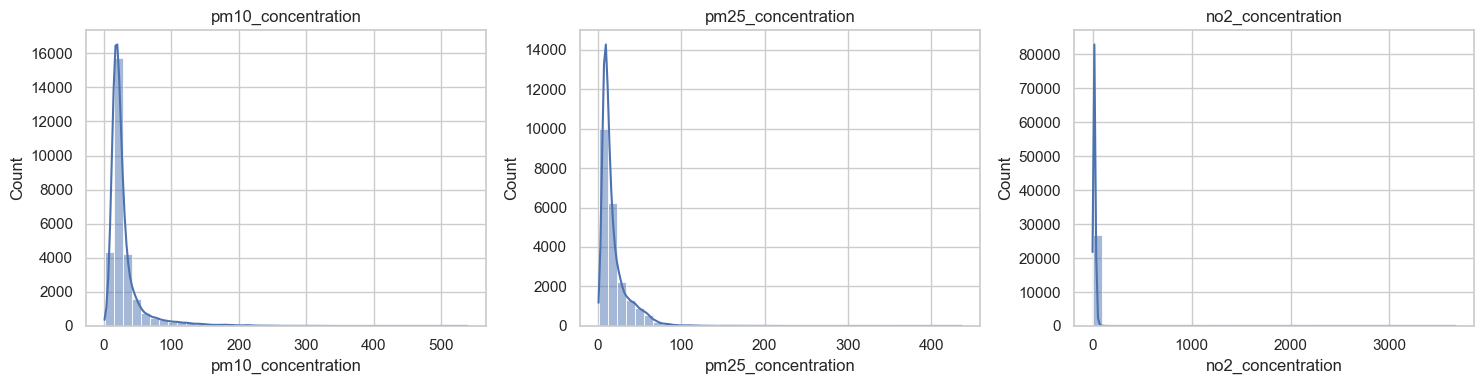

In [4]:
# Distribuciones de concentraciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["pm10_concentration", "pm25_concentration", "no2_concentration"]):
    sns.histplot(raw_df[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

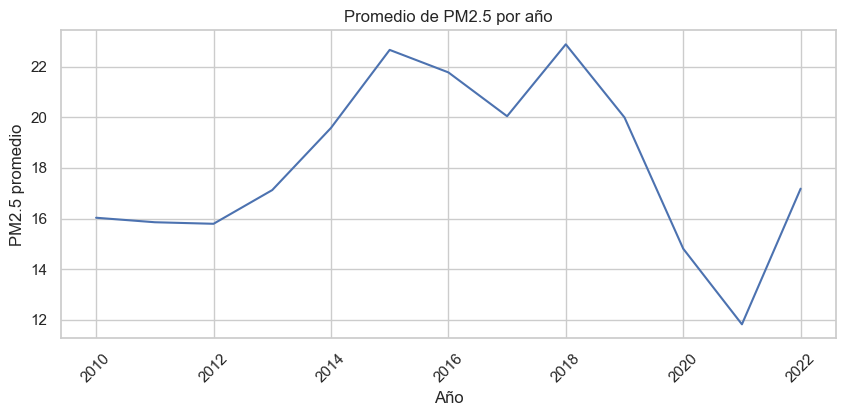

In [5]:
# Tendencia por año
trend = raw_df.groupby("year")["pm25_concentration"].mean().reset_index()
trend = trend.dropna()

plt.figure(figsize=(10, 4))
sns.lineplot(data=trend, x="year", y="pm25_concentration")
plt.title("Promedio de PM2.5 por año")
plt.xlabel("Año")
plt.ylabel("PM2.5 promedio")
plt.xticks(rotation=45)
plt.show()

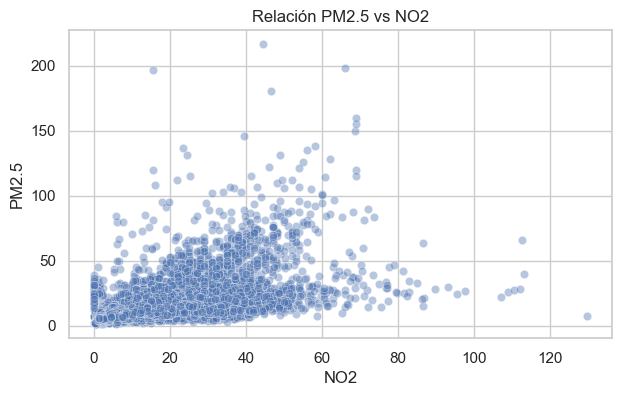

In [6]:
# Relación entre PM2.5 y NO2
plt.figure(figsize=(7, 4))
sns.scatterplot(data=raw_df, x="no2_concentration", y="pm25_concentration", alpha=0.4)
plt.title("Relación PM2.5 vs NO2")
plt.xlabel("NO2")
plt.ylabel("PM2.5")
plt.show()

In [7]:
# Resumen por región
region_summary = raw_df.groupby("who_region")["pm25_concentration"].agg(["mean", "median", "std", "count"]).reset_index()
region_summary.sort_values("mean", ascending=False)

,who_region,mean,median,std,count
2,3_Sear,55.794651,38.854,47.529963,410
4,5_Emr,41.112934,36.717,20.381454,183
5,6_Wpr,39.866606,38.513,18.734008,4405
0,1_Afr,28.597014,23.384,20.736119,140
6,7_NonMS,14.420000,14.300,1.413153,5
3,4_Eur,13.613745,12.329,6.569392,11577
1,2_Amr,9.585044,8.075,6.113225,5010


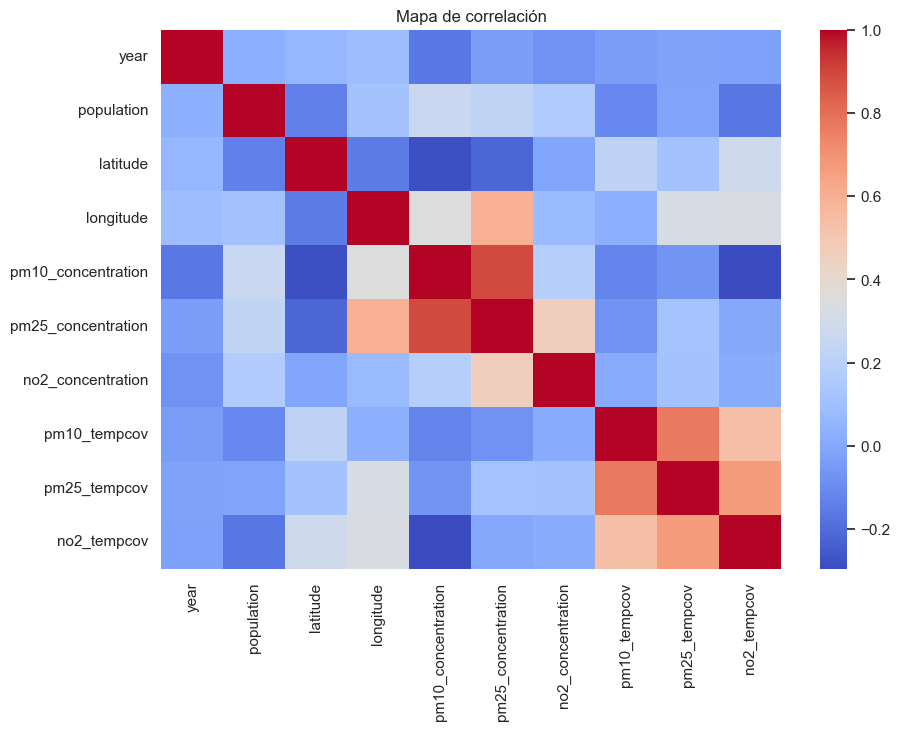

In [8]:
# Correlación numérica
plt.figure(figsize=(10, 7))
correlation_matrix = raw_df[numeric_cols].corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()